# Добавление библиотек и чтение файлов:

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Загружаем данные (устойчиво к рабочей директории ядра)
cwd = Path.cwd()
if (cwd / 'data' / 'processed').exists():
    processed_dir = cwd / 'data' / 'processed'
elif (cwd.parent / 'data' / 'processed').exists():
    processed_dir = cwd.parent / 'data' / 'processed'
else:
    # Последняя попытка — относительный путь
    processed_dir = Path('../data/processed')

train_path = processed_dir / 'train_ordinal_encoded.csv'
test_path = processed_dir / 'test_ordinal_encoded.csv'

#print('Используем processed_dir =', processed_dir.resolve())
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Разделяем на признаки (X) и целевую переменную (y)
# (Убедитесь, что название колонки целевой переменной - 'charges')
X_train = train_df.drop('charges', axis=1)
y_train = train_df['charges']
X_test = test_df.drop('charges', axis=1)
y_test = test_df['charges']
print('Данные успешно загружены и разделены на X и y.')
print(f"Размер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Данные успешно загружены и разделены на X и y.
Размер тренировочной выборки: (802, 6)
Размер тестовой выборки: (268, 6)


# Построим "Жадное" дерево, без ограничений глубины.

Оно будет расти, пока идеально не выучит Train.

~*зачем мы это делаем?*~

1. *Чтобы иметь точку отчета и показать эффект* **<До/После>** 
2. Зафиксировать худший сценарий.
3.  Показать проблему высокого разброса(High Variance)

и т.д.

In [2]:
# Обучаем дерево без ограничений
tree_unlimited = DecisionTreeRegressor(random_state=42)
tree_unlimited.fit(X_train, y_train)

# Считаем предсказания
y_train_pred = tree_unlimited.predict(X_train)
y_test_pred = tree_unlimited.predict(X_test)

# Проверяем метрики переобучения
print("Метрики на Train (должны быть идеальными):")
print(f"R2: {r2_score(y_train, y_train_pred):.4f} | MAE: ${mean_absolute_error(y_train, y_train_pred):.2f}")

print("\nМетрики на Test (покажут реальное качество):")
print(f"R2: {r2_score(y_test, y_test_pred):.4f} | MAE: ${mean_absolute_error(y_test, y_test_pred):.2f}")

Метрики на Train (должны быть идеальными):
R2: 0.9995 | MAE: $11.68

Метрики на Test (покажут реальное качество):
R2: 0.6688 | MAE: $3107.15


## Что означают метрики R2 и MAE?

Мы будем использовать 4 вида метрик:

1. **$MAE$(средняя абсолютная ошибка)** - находит среднее арифметическое всех ошибок(если модель ошиблась на 100 долларов вниз или вверх, для нее это одна и та же стоимость - 100 единиц)
2. **$MSE$(средняя квадратичная ошибка)** - возводит в квадрат ошибку перед усреднением. Измеряется в "квадратичных долларах" ($\$^2$)
3. **$RMSE$(корень из средней квадратичной ошибки)** - берет корень от MSE, то есть считывает также все в квадрате, но от среднего числа берет корень. RMSE очень чувствителен к крупным ошибкам (выбросам)
4. **$R^2$ (R2, коэффициент детерминации)** - Показывает долю объясненной дисперсии. Сравнивает модель с глупым предсказанием среднего значения для каждого пациента. Обычно от 0 до 1, но бывает и отрицательные значения(то есть лучше было бы использовать среднее значение для всех, чем использовать такой вариант).
    * $R^2 = 1$: Идеальное предсказание.
   * $R^2 = 0$: Модель работает на уровне предсказания константы (среднего).
   * $R^2 < 0$: Модель работает хуже, чем простое предсказание среднего значения.

#### Мы видим, что метрики на Train очень близки к идеальным, модель подстроилась под каждого конкретного человека из обучающего набора и запомнила его идеальную стоимость. Но, как только появляются новые пациенты, она начинает допускать огромные ошибки.

Мы зафиксировали переобучение, следовательно, в следующей ячейке мы построим график остатков(Residuals Plot), чтобы визуально показать, где именно ошибается дерево 

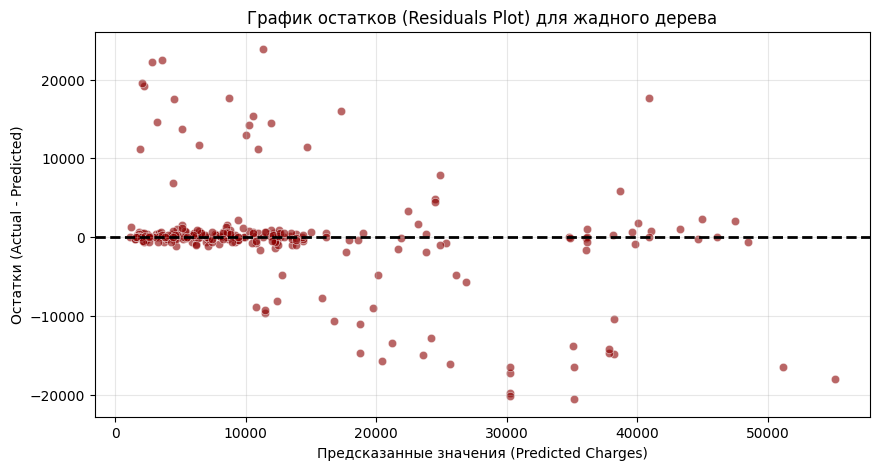

In [ ]:
# Вычисляем остатки (реальные значения минус предсказанные)
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6, color='darkred')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.title('График остатков (Residuals Plot) для жадного дерева')
plt.xlabel('Предсказанные значения (Predicted Charges)')
plt.ylabel('Остатки (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.show()